In [5]:
from langgraph.graph import StateGraph  , START , END
from typing import TypedDict , Literal

In [6]:
class QuadState(TypedDict):

    a: int 
    b:int
    c: int 

    equation : str 
    discriminant : str 
    result: str 

In [19]:
def show_equation(state : QuadState):

    equation = f'{state["a"]} x2{state["b"] }x {state["c"]}'


    return {'equation': equation}



def calculate_discriminant(state: QuadState):

    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {'discriminant' : discriminant}

In [20]:
graph = StateGraph(QuadState)

graph.add_node('show_equation' , show_equation)
graph.add_node('calculate_discriminant' , calculate_discriminant)


graph.add_edge(START ,'show_equation' )
graph.add_edge('show_equation' ,'calculate_discriminant' )
graph.add_edge('calculate_discriminant' ,END)


workflow = graph.compile()



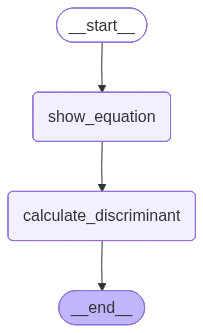

In [21]:
workflow

In [22]:
initial_state = {
    'a':4 , 
    'b':-5, 
    'c':-4,
}

workflow.invoke(initial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4 x2-5x -4', 'discriminant': 89}